          Name  Math  Science  English
0    Student_1  84.0       49       90
1    Student_2  87.0       60       63
2    Student_3  93.0       91       69
3    Student_4   NaN       56       35
4    Student_5  43.0       91       35
5    Student_6  99.0       45       71
6    Student_7  43.0       55       88
7    Student_8  79.0       87       40
8    Student_9  49.0       40       73
9   Student_10  59.0       58       52
10  Student_11  61.0       75       39
11  Student_12  90.0       64       77
12  Student_13  76.0       89       93
13  Student_14  63.0       91       66
14  Student_15  46.0       69       36
15  Student_16  64.0       59       76
16  Student_17  64.0       59       92
17  Student_18  52.0       54       70
18  Student_19  98.0       79       46
19  Student_20  41.0       72       81
20  Student_21  78.0       41       35
21  Student_22  79.0       49       49
22  Student_23  63.0       97       88
23  Student_24  86.0       72       47
24  Student_25  64.0     

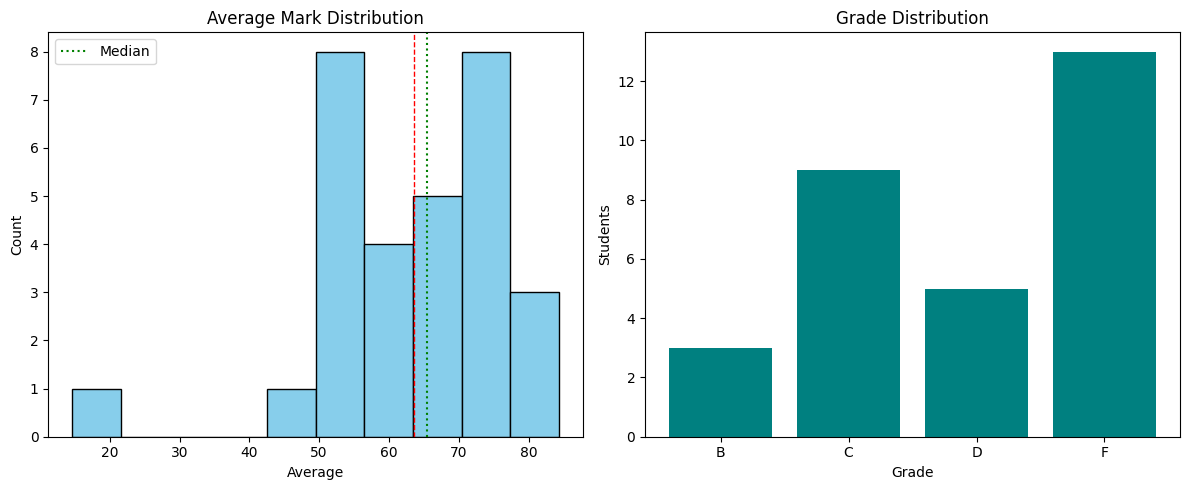

Saved to class_statistics.csv


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n=30
dt={
    'Name': [f'Student_{i}'for i in range(1, n+1)],
    'Math':np.random.randint(40, 100, n),
    'Science':np.random.randint(40, 100, n),
    'English':np.random.randint(35, 100, n)
}
df= pd.DataFrame(dt)

df.loc[3, 'Math'] = np.nan
print(df)
df.loc[12, 'Science'] = np.nan
df.loc[5, 'English'] = -100

print('-'*5,'Basic Info','-'*5)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data Types:\n{df.dtypes}")
print(df.isnull().sum())

for col in ['Math', 'Science', 'English']:
    df[col]=df[col].fillna(df[col].median())

df['Total']=df[['Math', 'Science', 'English']].sum(axis=1)
df['Average']=df['Total']/3
print(df['Total'])
print(df['Average'])

avg=df['Average'].values
print('-'*5,'Statistics','-'*5)
print(f"Mean: {np.mean(avg):.2f}")
print(f"Median: {np.median(avg):.2f}")
print(f"Standard Deviation: {np.std(avg):.2f}")
print(f"Min: {np.min(avg):.2f}")
print(f"Max: {np.max(avg):.2f}")
q1,q3=np.percentile(avg, [25, 75])
iqr=q3-q1
print(f'Q1/Q3:{q1:.2f}/{q3:.2f}|IQR:{iqr:.2f}')
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[(avg < lower_bound) | (avg > upper_bound)]
print(f"Outliers:{len(outliers)} students(s)")
if len(outliers):
    print(outliers[['Name', 'Average']])

def assign_grade(a):
    if a >= 90:
        return 'A'
    elif a >= 80:
        return 'B'
    elif a >= 70:
        return 'C'
    elif a >= 60:
        return 'D'
    else:
        return 'F'
df['Grade']=df['Average'].apply(assign_grade)

fig,(ax1, ax2)=plt.subplots(1,2, figsize=(12,5))
ax1.hist(df['Average'], bins=10, color='skyblue', edgecolor='black')
ax1.axvline(np.mean(avg), color='red', linestyle='dashed', linewidth=1)
ax1.axvline(np.median(avg),color='green',linestyle=':',label="Median")

ax1.set_title('Average Mark Distribution')
ax1.set_xlabel('Average')
ax1.set_ylabel('Count')
ax1.legend()

grade_counts = df['Grade'].value_counts().sort_index() 
ax2.bar(grade_counts.index, grade_counts.values, color='teal') 
ax2.set_title('Grade Distribution') 
ax2.set_xlabel('Grade')
ax2.set_ylabel('Students') 
plt.tight_layout() 
plt.savefig('class_stats.png', dpi=150) 
plt.show()
df.to_csv('class_statistics.csv', index=False)
print('Saved to class_statistics.csv')
